<a href="https://colab.research.google.com/github/betulbilhan2/LLM-Augmentation-Fidelity/blob/main/NB09_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 09: Statistical Analysis

**Objectives:**
1. **Friedman Test:** Perform non-parametric ANOVA on 4 scenarios (E0-E3) using 10 seeds as blocking variables.
2. **Post-hoc Wilcoxon Signed-Rank Test:** Pairwise comparisons with Holm correction for multiple testing.
3. **Effect Size (Rank-Biserial Correlation):** Measure the magnitude of differences between augmentation strategies.
4. **Bootstrap Confidence Intervals:** Calculate 95% CIs to transparently report the uncertainty due to $N=10$ seeds.
5. **Visualizations:** Generate publication-ready plots (Boxplots, Heatmaps) for the manuscript.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Plotting style for publication
sns.set_theme(style="whitegrid", font_scale=1.1)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tr_augmentation_project'
    IN_COLAB = True
except:
    BASE_DIR = 'C:/Users/btlbi/OneDrive/Masaustu/TR Veri arttirimi'
    IN_COLAB = False

EVAL_DIR = os.path.join(BASE_DIR, '08_evaluation')
STATS_DIR = os.path.join(BASE_DIR, '09_statistics')
os.makedirs(STATS_DIR, exist_ok=True)

print("Directories are set up.")

Mounted at /content/drive
Directories are set up.


## 1. Data Loading
Load the `all_results_long_format.csv` file generated in NB08. We will verify that exactly 80 rows exist (2 Resource Levels $\times$ 4 Scenarios $\times$ 10 Seeds).

In [ ]:
data_path = os.path.join(EVAL_DIR, 'all_results_long_format.csv')
df = pd.read_csv(data_path)

print(f"Total records loaded: {len(df)} (Expected: 80)")
assert len(df) == 80, "Warning: The dataset should have exactly 80 rows."

display(df.head())

Total records loaded: 80 (Expected: 80)


,resource_level,scenario,seed,train_time_sec,macro_f1,f1_negative,f1_neutral,f1_positive
0,low,E0,0,299.111069,0.525804,0.270468,0.746434,0.560511
1,low,E0,1,523.016380,0.615918,0.376279,0.761298,0.710176
2,low,E0,2,351.816885,0.499033,0.195929,0.723394,0.577775
3,low,E0,3,348.005420,0.535014,0.165700,0.742866,0.696475
4,low,E0,4,265.881076,0.495876,0.063855,0.750088,0.673685


## 2. Friedman Test
The Friedman test is a non-parametric alternative to one-way repeated measures ANOVA.
We perform the test **separately for each resource level** (`low` and `normal`), using the 10 data seeds as **blocking variables**.

In [ ]:
levels = ['low', 'normal']
scenarios = ['E0', 'E1', 'E2', 'E3']

friedman_results = []

for level in levels:
    df_sub = df[df['resource_level'] == level]
    # Pivot ensures seeds are rows and scenarios are columns, aligning pairs properly
    pivot_df = df_sub.pivot(index='seed', columns='scenario', values='macro_f1')

    # Perform Friedman Test across E0, E1, E2, E3
    stat, p_value = stats.friedmanchisquare(
        pivot_df['E0'], pivot_df['E1'], pivot_df['E2'], pivot_df['E3']
    )

    friedman_results.append({
        'Resource Level': level,
        'Friedman Stat': round(stat, 4),
        'p-value': p_value,
        'Significant': p_value < 0.05
    })

df_friedman = pd.DataFrame(friedman_results)
display(df_friedman)
df_friedman.to_csv(os.path.join(STATS_DIR, 'friedman_test_results.csv'), index=False)

,Resource Level,Friedman Stat,p-value,Significant
0,low,0.84,0.839878,False
1,normal,24.24,0.000022,True


## 3. Post-hoc Wilcoxon Signed-Rank Test & Effect Sizes
If the Friedman test is significant, we perform pairwise Wilcoxon Signed-Rank tests.
To avoid Type-I error inflation, we apply the **Holm correction**.

We also compute:
- **Rank-Biserial Correlation (r)**: Effect size metric.
- **95% Bootstrap Confidence Interval**: To transparently show the uncertainty margin.

In [ ]:
def rank_biserial_correlation(x, y):
    """Calculates Rank-Biserial Correlation for Wilcoxon Signed-Rank Test."""
    diff = np.array(x) - np.array(y)
    diff = diff[diff != 0] # Remove ties
    if len(diff) == 0: return 0.0
    pos_ranks = np.sum(diff > 0)
    neg_ranks = np.sum(diff < 0)
    return (pos_ranks - neg_ranks) / (pos_ranks + neg_ranks)

def bootstrap_mean_diff_ci(x, y, n_boot=10000, ci=0.95):
    """Calculates Bootstrap Confidence Interval for the mean difference."""
    diff = np.array(x) - np.array(y)
    # Random sampling with replacement
    boot_means = [np.mean(np.random.choice(diff, len(diff), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_means, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return lower, upper

pairs = list(combinations(scenarios, 2))
posthoc_results = []

for level in levels:
    df_sub = df[df['resource_level'] == level]
    pivot_df = df_sub.pivot(index='seed', columns='scenario', values='macro_f1')

    p_values, w_stats, r_effects, ci_lowers, ci_uppers, mean_diffs = [], [], [], [], [], []

    for s1, s2 in pairs:
        x, y = pivot_df[s1], pivot_df[s2]

        # 1. Wilcoxon Test
        res = stats.wilcoxon(x, y, zero_method='pratt')
        w_stats.append(res.statistic)
        p_values.append(res.pvalue)

        # 2. Effect Size
        r_effects.append(rank_biserial_correlation(x, y))

        # 3. Mean Difference & Bootstrap CI
        mean_diffs.append(np.mean(x - y))
        ci_l, ci_u = bootstrap_mean_diff_ci(x, y)
        ci_lowers.append(ci_l)
        ci_uppers.append(ci_u)

    # Holm Correction per resource level (6 comparisons each)
    reject, pvals_corrected, _, _ = multipletests(p_values, method='holm')

    for i, (s1, s2) in enumerate(pairs):
        posthoc_results.append({
            'Resource Level': level,
            'Pair': f"{s1} vs {s2}",
            'Mean Diff': mean_diffs[i],
            'W-Stat': w_stats[i],
            'p-value (raw)': p_values[i],
            'p-value (Holm)': pvals_corrected[i],
            'Significant': reject[i],
            'Effect Size (r)': r_effects[i],
            'CI 95% Lower': ci_lowers[i],
            'CI 95% Upper': ci_uppers[i]
        })

df_posthoc = pd.DataFrame(posthoc_results)
display(df_posthoc)
df_posthoc.to_csv(os.path.join(STATS_DIR, 'wilcoxon_pairwise_results.csv'), index=False)


,Resource Level,Pair,Mean Diff,W-Stat,p-value (raw),p-value (Holm),Significant,Effect Size (r),CI 95% Lower,CI 95% Upper
0,low,E0 vs E1,-0.046282,15.0,0.232422,1.000000,False,-0.2,-0.096051,0.002352
1,low,E0 vs E2,-0.033793,16.0,0.275391,1.000000,False,-0.2,-0.077861,0.010377
2,low,E0 vs E3,-0.042472,14.0,0.193359,1.000000,False,-0.2,-0.088001,0.003589
3,low,E1 vs E2,0.012488,24.0,0.769531,1.000000,False,-0.2,-0.020134,0.044837
4,low,E1 vs E3,0.003810,27.0,1.000000,1.000000,False,0.0,-0.040476,0.052405
5,low,E2 vs E3,-0.008678,22.0,0.625000,1.000000,False,0.0,-0.041206,0.027225
6,normal,E0 vs E1,-0.079507,0.0,0.001953,0.011719,True,-1.0,-0.099459,-0.060317
7,normal,E0 vs E2,-0.043607,0.0,0.001953,0.011719,True,-1.0,-0.061860,-0.025415
8,normal,E0 vs E3,-0.053323,0.0,0.001953,0.011719,True,-1.0,-0.077542,-0.031377
9,normal,E1 vs E2,0.035900,3.0,0.009766,0.019531,True,0.8,0.017910,0.055142


## 4. Visualizations: Macro-F1 Boxplot
A highly informative, publication-ready plot showing distributions, medians, and individual seed performances.

/tmp/ipykernel_547/125378910.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sub, x='scenario', y='macro_f1', order=order,
/tmp/ipykernel_547/125378910.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sub, x='scenario', y='macro_f1', order=order,


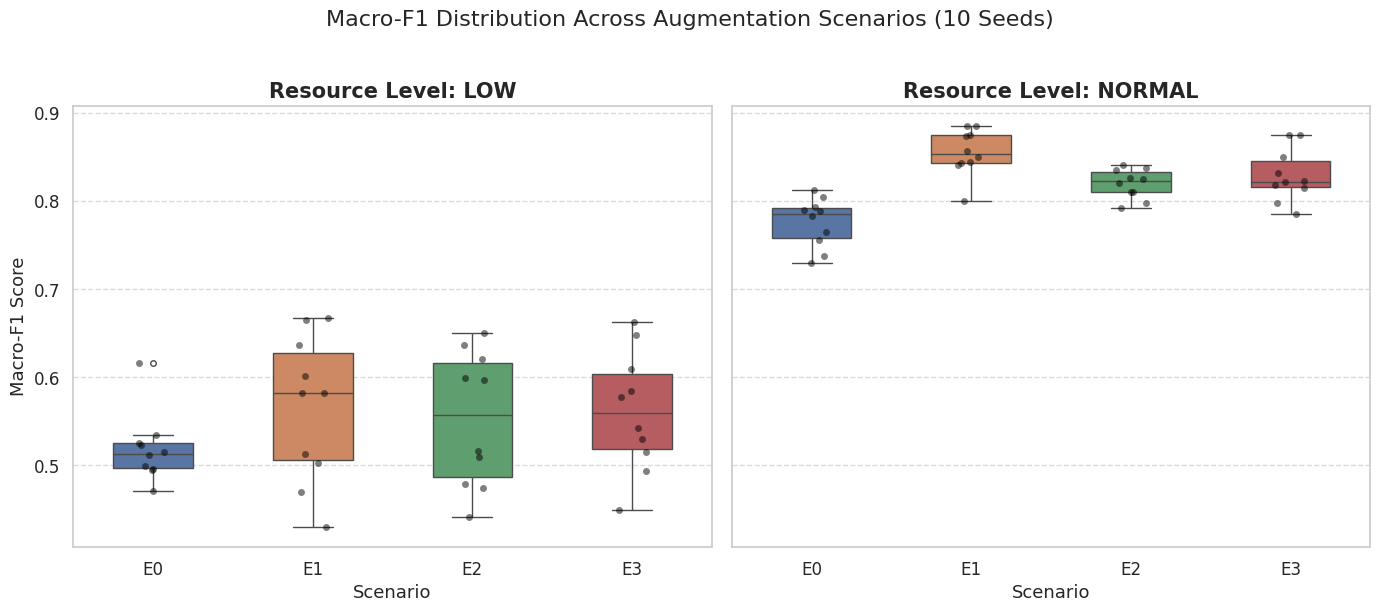

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Consistent coloring with previous plots
palette = {'E0': '#4C72B0', 'E1': '#DD8452', 'E2': '#55A868', 'E3': '#C44E52'}
order = ['E0', 'E1', 'E2', 'E3']

for idx, level in enumerate(levels):
    ax = axes[idx]
    df_sub = df[df['resource_level'] == level]

    # Boxplot for distribution
    sns.boxplot(data=df_sub, x='scenario', y='macro_f1', order=order,
                palette=palette, ax=ax, width=0.5,
                flierprops={'marker': 'o', 'markersize': 4})

    # Overlay points to transparently show 10 seeds
    sns.stripplot(data=df_sub, x='scenario', y='macro_f1', order=order,
                  ax=ax, color='black', alpha=0.5, size=5, jitter=True)

    ax.set_title(f"Resource Level: {level.upper()}", fontsize=15, fontweight='bold')
    ax.set_xlabel("Scenario", fontsize=13)
    if idx == 0:
        ax.set_ylabel("Macro-F1 Score", fontsize=13)
    else:
        ax.set_ylabel("")

    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Macro-F1 Distribution Across Augmentation Scenarios (10 Seeds)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(STATS_DIR, 'boxplot_macro_f1.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Visualizations: P-Value Heatmap
Visualizing the Holm-corrected p-values. Green indicates statistically significant differences ($p < 0.05$).

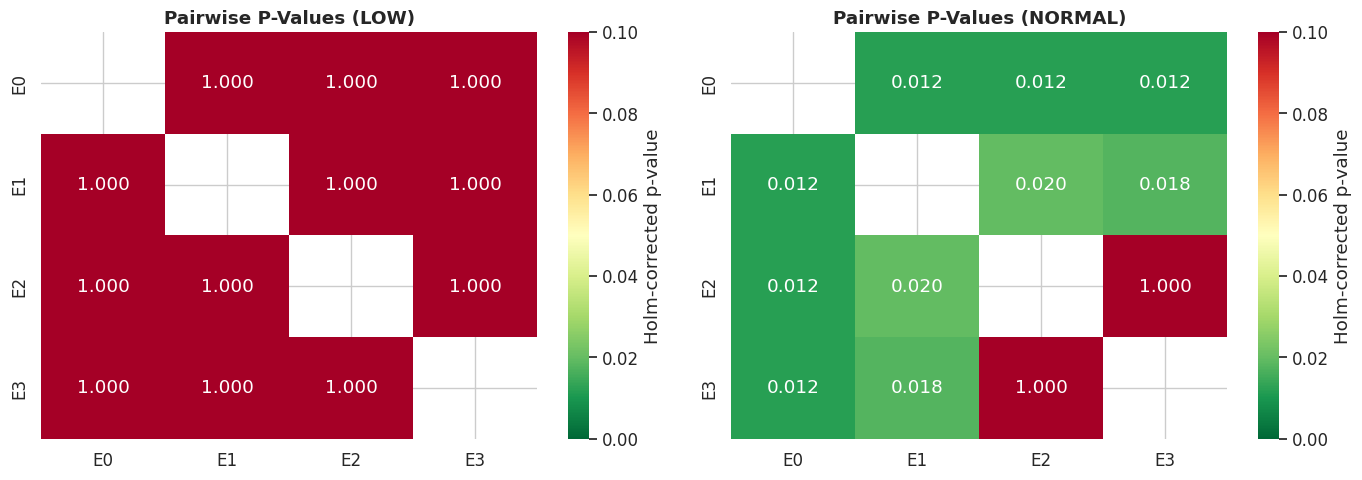

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, level in enumerate(levels):
    df_sub = df_posthoc[df_posthoc['Resource Level'] == level]

    pval_matrix = pd.DataFrame(np.ones((4, 4)), index=scenarios, columns=scenarios)
    for _, row in df_sub.iterrows():
        s1, s2 = row['Pair'].split(' vs ')
        pval_matrix.loc[s1, s2] = row['p-value (Holm)']
        pval_matrix.loc[s2, s1] = row['p-value (Holm)']

    ax = axes[idx]
    mask = np.eye(4, dtype=bool)

    # Colormap: Green (significant) to Red (insignificant)
    sns.heatmap(pval_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', mask=mask,
                ax=ax, vmin=0, vmax=0.1,
                cbar_kws={'label': 'Holm-corrected p-value'})

    ax.set_title(f"Pairwise P-Values ({level.upper()})", fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(STATS_DIR, 'pvalue_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. LaTeX Table Export for the Manuscript
Generates properly formatted LaTeX tables so you can copy and paste them directly into your paper.

In [ ]:
# 1. Summary Statistics Table
summary = df.groupby(['resource_level', 'scenario']).agg(
    macro_mean=('macro_f1', 'mean'),
    macro_std=('macro_f1', 'std')
).reset_index()

# Hem Math mode ($...$) eklendi, hem de rf"..." yapılarak \p uyarısı kalıcı olarak çözüldü
summary[r'Macro-F1 (Mean $\pm$ Std)'] = summary.apply(lambda row: rf"${row['macro_mean']:.4f} \pm {row['macro_std']:.4f}$", axis=1)
summary_pivot = summary.pivot(index='scenario', columns='resource_level', values=r'Macro-F1 (Mean $\pm$ Std)')
summary_pivot = summary_pivot[['low', 'normal']] # Order columns

print("% --- Summary Statistics Table ---")
try:
    print(summary_pivot.style.to_latex(caption=r"Macro-F1 Scores (Mean $\pm$ Std over 10 Seeds)", label="tab:summary_stats", hrules=True))
except AttributeError:
    print(summary_pivot.to_latex(caption=r"Macro-F1 Scores (Mean $\pm$ Std over 10 Seeds)", label="tab:summary_stats"))


print("\n\n% --- Post-hoc Statistical Test Table ---")
latex_df = df_posthoc[['Resource Level', 'Pair', 'Mean Diff', 'p-value (Holm)', 'Effect Size (r)', 'CI 95% Lower', 'CI 95% Upper']].copy()

latex_df['Mean Diff'] = latex_df['Mean Diff'].apply(lambda x: f"{x:+.4f}")
latex_df['p-value (Holm)'] = latex_df['p-value (Holm)'].apply(lambda x: f"{x:.4f}" if x >= 0.0001 else "<0.0001")
latex_df['Effect Size (r)'] = latex_df['Effect Size (r)'].apply(lambda x: f"{x:+.2f}")

# % işareti \% yapılarak LaTeX'in yorum satırı sanması engellendi!
latex_df[r'95\% CI'] = latex_df.apply(lambda row: f"[{row['CI 95% Lower']:.4f}, {row['CI 95% Upper']:.4f}]", axis=1)
latex_df = latex_df.drop(columns=['CI 95% Lower', 'CI 95% Upper'])

try:
    print(latex_df.style.hide(axis="index").to_latex(caption="Wilcoxon Signed-Rank Test Results with Holm Correction", label="tab:stats_results", hrules=True))
except AttributeError:
    try:
        print(latex_df.style.hide_index().to_latex(caption="Wilcoxon Signed-Rank Test Results with Holm Correction", label="tab:stats_results", hrules=True))
    except AttributeError:
        print(latex_df.to_latex(index=False, caption="Wilcoxon Signed-Rank Test Results with Holm Correction", label="tab:stats_results"))

% --- Summary Statistics Table ---
\begin{table}
\caption{Macro-F1 Scores (Mean $\pm$ Std over 10 Seeds)}
\label{tab:summary_stats}
\begin{tabular}{lll}
\toprule
resource_level & low & normal \\
scenario &  &  \\
\midrule
E0 & $0.5188 \pm 0.0389$ & $0.7762 \pm 0.0279$ \\
E1 & $0.5651 \pm 0.0825$ & $0.8557 \pm 0.0262$ \\
E2 & $0.5526 \pm 0.0764$ & $0.8198 \pm 0.0165$ \\
E3 & $0.5613 \pm 0.0680$ & $0.8296 \pm 0.0297$ \\
\bottomrule
\end{tabular}
\end{table}



% --- Post-hoc Statistical Test Table ---
\begin{table}
\caption{Wilcoxon Signed-Rank Test Results with Holm Correction}
\label{tab:stats_results}
\begin{tabular}{llllll}
\toprule
Resource Level & Pair & Mean Diff & p-value (Holm) & Effect Size (r) & 95\% CI \\
\midrule
low & E0 vs E1 & -0.0463 & 1.0000 & -0.20 & [-0.0961, 0.0024] \\
low & E0 vs E2 & -0.0338 & 1.0000 & -0.20 & [-0.0779, 0.0104] \\
low & E0 vs E3 & -0.0425 & 1.0000 & -0.20 & [-0.0880, 0.0036] \\
low & E1 vs E2 & +0.0125 & 1.0000 & -0.20 & [-0.0201, 0.0448] \\
low & 